gender - 성별
race/ethnicity - 인종/민족
parental level of education - 부모의 교육 수준(학력)
lunch - 점심식사(무료,할인 급식과 일반 급식의 차이)
test preparation course - 시험 준비 과정
math score - 수학 점수
reading score - 읽기 점수
writing score - 쓰기 점수

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=True)

In [4]:
# 데이터 로드
data = pd.read_csv('data/StudentsPerformance.csv')
print(data.shape)
data

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
# 데이터 확인
display(data.describe())
display(data.describe(include='str'))

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [6]:
print(data.value_counts('gender'))
print('\n')
print(data.value_counts('race/ethnicity'))
print('\n')
print(data.value_counts('parental level of education'))
print('\n')
print(data.value_counts('lunch'))
print('\n')
print(data.value_counts('test preparation course'))

gender
female    518
male      482
Name: count, dtype: int64


race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


lunch
standard        645
free/reduced    355
Name: count, dtype: int64


test preparation course
none         642
completed    358
Name: count, dtype: int64


In [ ]:
# 총 점 추가 => 학생들의 전체 성취도를 직관적으로 확인하기 위해 평균이 아닌 합산을 사용 (스케일 기준이 동일)
data['total score'] = data['math score'] + data['writing score'] + data['reading score']
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282
996,male,group C,high school,free/reduced,none,62,55,55,172
997,female,group C,high school,free/reduced,completed,59,71,65,195
998,female,group D,some college,standard,completed,68,78,77,223


In [8]:
# 결측치 확인
print(data.duplicated().sum())  
print(data.isna().sum())

0
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
total score                    0
dtype: int64


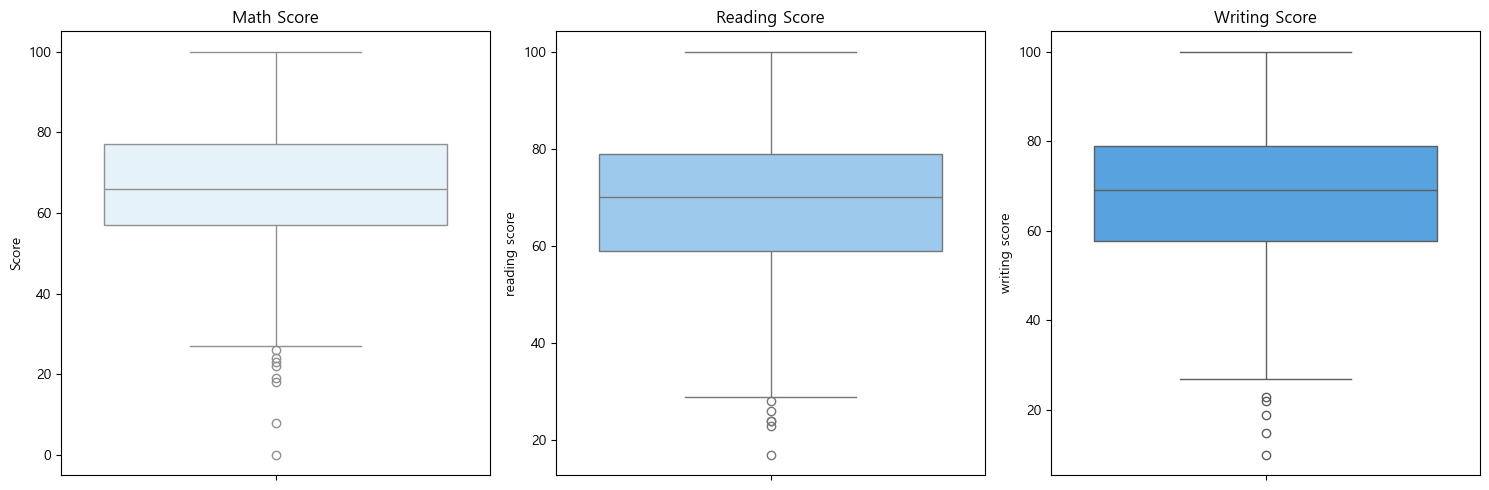

In [ ]:
# 이상치 확인을 위해 Boxplot 사용
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data['math score'],ax=ax[0],color='#E3F2FD')
ax[0].set_title('Math Score')
ax[0].set_ylabel('Score')

sns.boxplot(data['reading score'],ax=ax[1],color='#90CAF9')
ax[1].set_title('Reading Score')

sns.boxplot(data['writing score'],ax=ax[2],color='#42A5F5')
ax[2].set_title('Writing Score')

plt.tight_layout()
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_27588\3208841119.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='gender', palette='Set1')


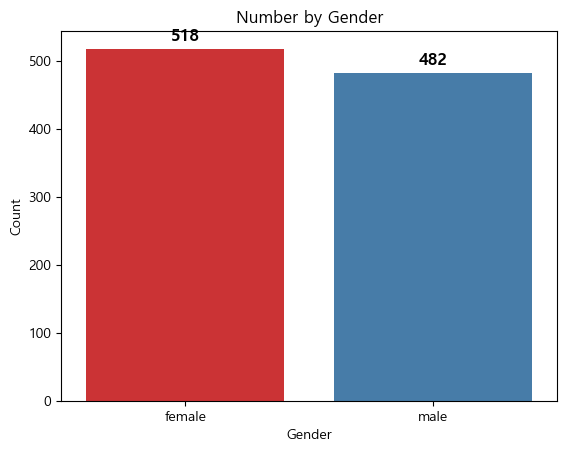

In [10]:
ax = sns.countplot(data=data, x='gender', palette='Set1')

# 각 막대 위에 숫자(수도) 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Number by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

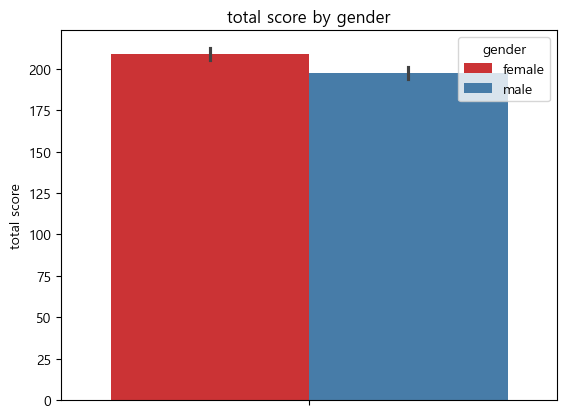

In [11]:
sns.barplot(data=data,y='total score',hue='gender',palette='Set1')
plt.title('total score by gender')
plt.show()

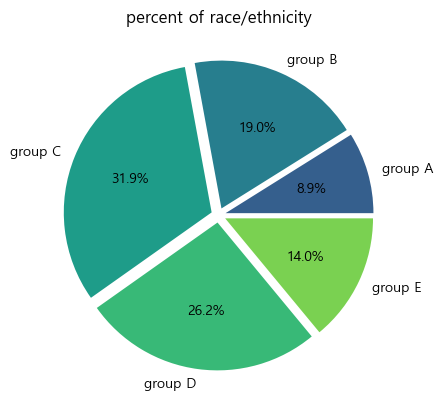

In [12]:
plt.title('percent of race/ethnicity')
share = data['race/ethnicity'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(share)))
plt.pie(share, labels=share.index,
        autopct='%1.1f%%',           # 퍼센트 표시
        startangle=0,
        explode=[0.05] * len(share), 
        colors=colors
) 

plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_27588\859701546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data,y='total score',x='race/ethnicity',order=order,palette=colors)
C:\Users\test\AppData\Local\Temp\ipykernel_27588\859701546.py:2: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(data=data,y='total score',x='race/ethnicity',order=order,palette=colors)


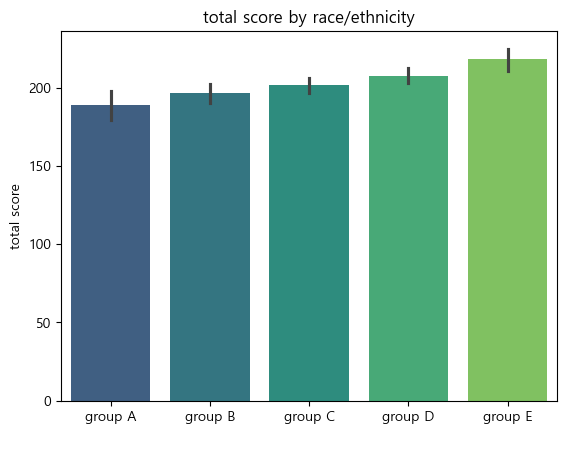

In [13]:
order = data.groupby('race/ethnicity')['total score'].mean().sort_values().index
sns.barplot(data=data,y='total score',x='race/ethnicity',order=order,palette=colors)
plt.title('total score by race/ethnicity')
plt.xlabel(' ')
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_27588\3402585141.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, y='parental level of education', palette='viridis',order=data['parental level of education'].value_counts().index)


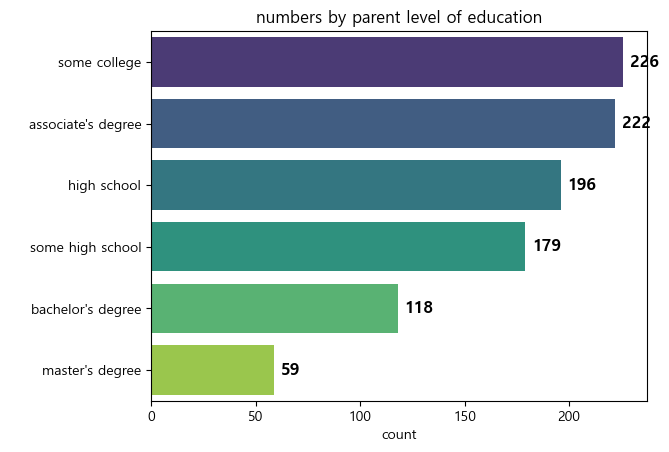

In [14]:
ax = sns.countplot(data=data, y='parental level of education', palette='viridis',order=data['parental level of education'].value_counts().index)

# 각 막대 위에 숫자(수도) 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha = 'left', va = 'center', 
                xytext = (5, 0),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('numbers by parent level of education')
plt.ylabel(' ')
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_27588\2807473164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data,x='total score',y='parental level of education',order=order,palette='viridis')


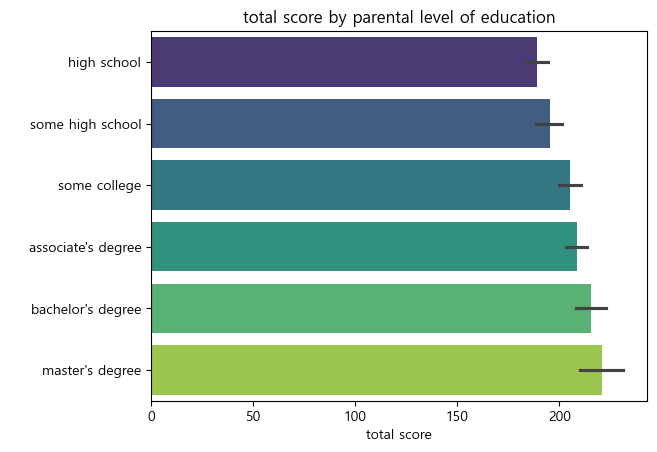

In [15]:
order = data.groupby('parental level of education')['total score'].mean().sort_values().index
sns.barplot(data=data,x='total score',y='parental level of education',order=order,palette='viridis')
plt.title('total score by parental level of education')
plt.ylabel(' ')
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_27588\2280077006.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='lunch', palette='Set3')


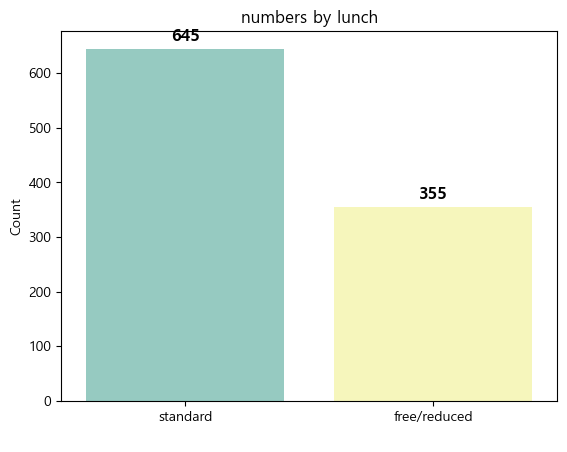

In [16]:
ax = sns.countplot(data=data, x='lunch', palette='Set3')

# 각 막대 위에 숫자(수도) 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('numbers by lunch')
plt.xlabel(' ')
plt.ylabel('Count')
plt.show()

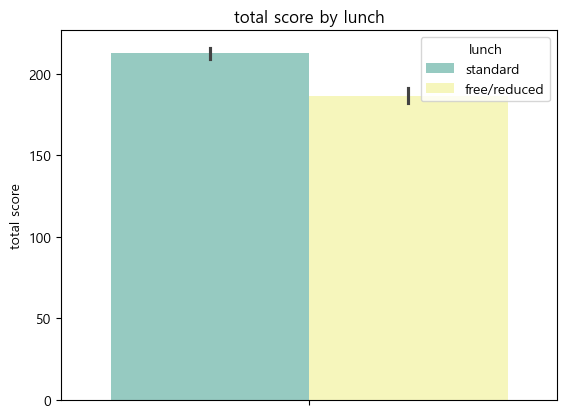

In [17]:
sns.barplot(data=data,y='total score',hue='lunch',palette='Set3')
plt.title('total score by lunch')
plt.show()

C:\Users\test\AppData\Local\Temp\ipykernel_27588\2664935535.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='test preparation course', palette='husl')


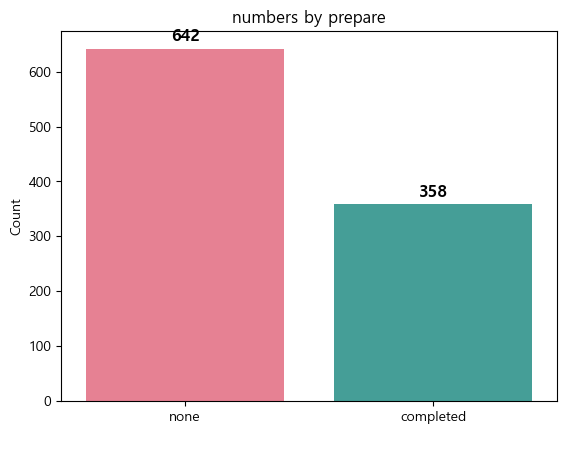

In [18]:
ax = sns.countplot(data=data, x='test preparation course', palette='husl')

# 각 막대 위에 숫자(수도) 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('numbers by prepare')
plt.xlabel(' ')
plt.ylabel('Count')
plt.show()

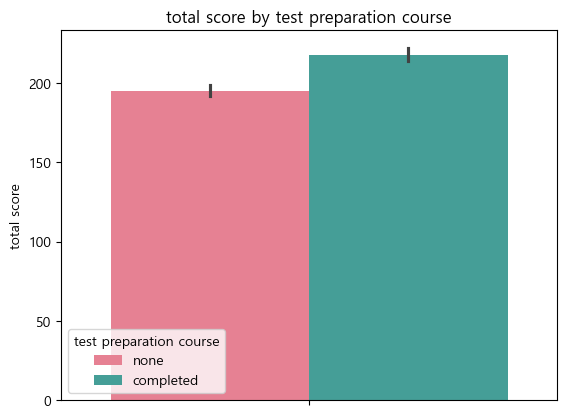

In [19]:
sns.barplot(data=data,y='total score',hue='test preparation course',palette='husl')
plt.title('total score by test preparation course')
plt.show()

<Axes: xlabel='writing score', ylabel='reading score'>

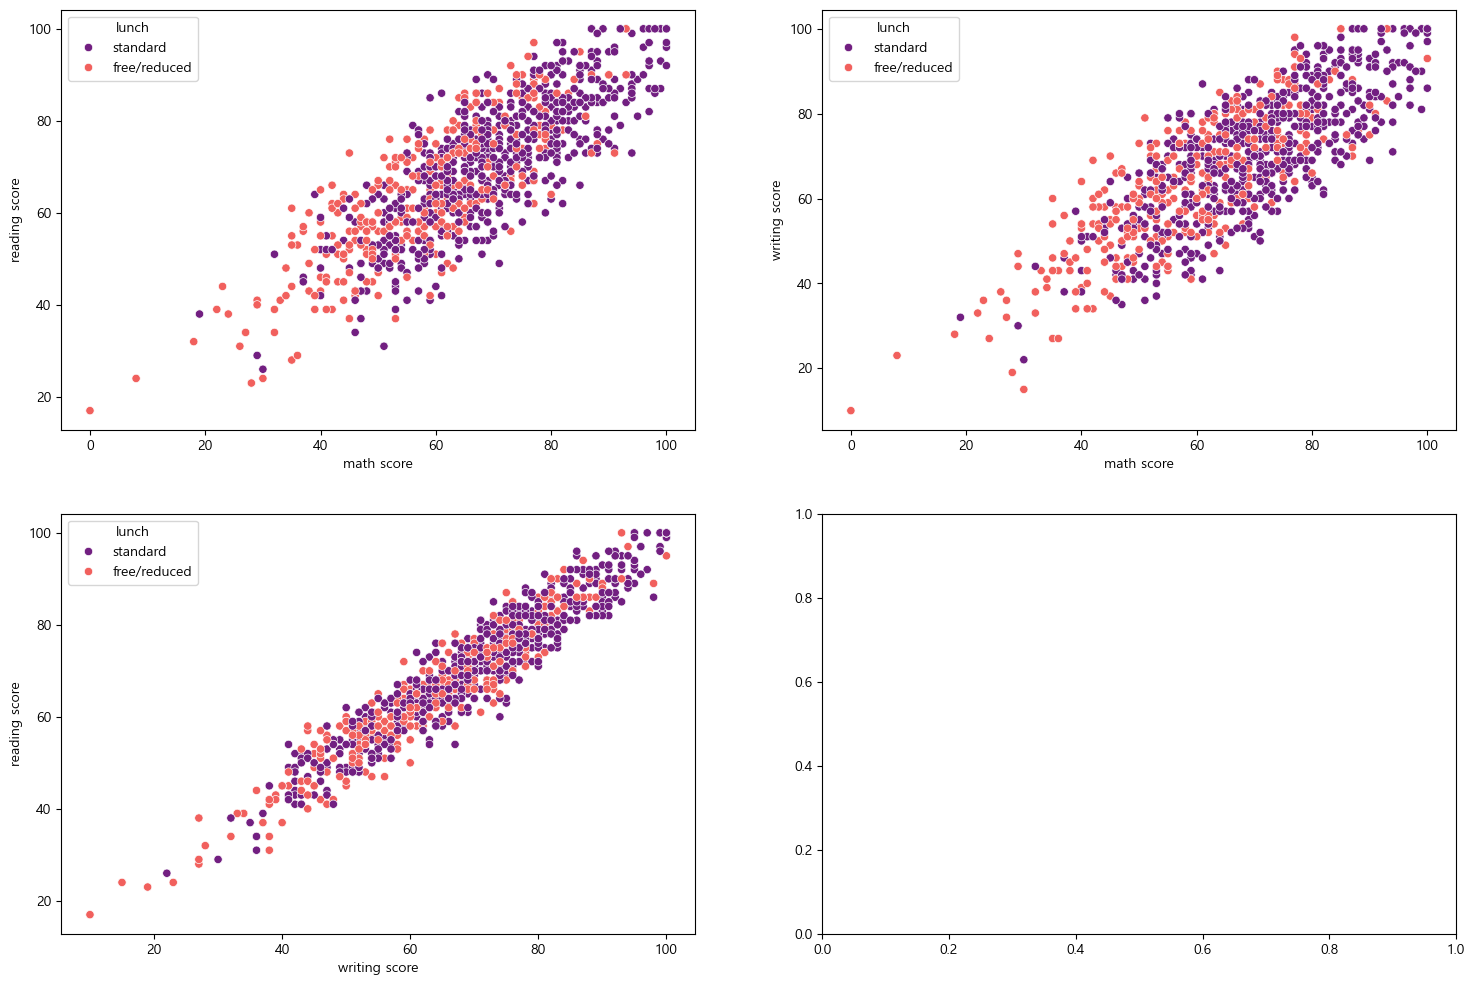

In [21]:
fig, ax = plt.subplots(2,2,figsize = (18,12))
sns.scatterplot(data=data,x='math score', y='reading score',hue='lunch',palette='magma',ax=ax[0,0])
sns.scatterplot(data=data,x='math score', y='writing score',hue='lunch',palette='magma',ax=ax[0,1])
sns.scatterplot(data=data,x='writing score', y='reading score',hue='lunch',palette='magma',ax=ax[1,0])